In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [19]:
def cos2_function(theta, a, b):
    """
    코사인 제곱 피팅 함수: a + b * cos²(theta)
    a: 오프셋
    b: 진폭
    """
    return a + b * np.cos(theta)**2

# 2. 데이터로부터 피팅 수행
def fit_cos2(theta_data, y_data, yerr=None):
    """
    주어진 데이터에 cos² 함수를 피팅합니다
    """
    # 초기 파라미터 추정
    initial_params = [np.min(y_data), np.max(y_data) - np.min(y_data)]
    
    # 피팅 수행
    params, pcov = curve_fit(cos2_function, theta_data, y_data, p0=initial_params, sigma=yerr)
    
    # 에러 계산
    perr = np.sqrt(np.diag(pcov))
    
    # 결과 출력
    a, b = params
    a_err, b_err = perr
    
    print(f"피팅 결과:")
    print(f"a (오프셋) = {a:.6f} ± {a_err:.6f}")
    print(f"b (진폭) = {b:.6f} ± {b_err:.6f}")
    
    # χ² 계산
    if yerr is not None:
        y_fit = cos2_function(theta_data, *params)
        chi2 = np.sum(((y_data - y_fit) / yerr)**2)
        dof = len(y_data) - len(params)
        print(f"χ²/dof = {chi2:.2f}/{dof} = {chi2/dof:.2f}")
    
    return params, perr
def plot_fit_result(theta_data, y_data, yerr=None, params=None):
    """
    데이터와 피팅 결과를 시각화합니다
    """
    plt.figure(figsize=(10, 6))
    
    # 데이터 플롯
    if yerr is not None:
        plt.errorbar(theta_data, y_data, yerr=yerr, fmt='o', label='Data')
    else:
        plt.scatter(theta_data, y_data, label='Data')
    
    # 피팅 곡선 플롯
    if params is not None:
        theta_fine = np.linspace(min(theta_data), max(theta_data), 1000)
        y_fit = cos2_function(theta_fine, *params)
        plt.plot(theta_fine, y_fit, 'r-', label=f'Fit: {params[0]:.4f} + {params[1]:.4f} × cos²(θ)')
    
    plt.xlabel(r'$\theta$ (radians)')
    plt.ylabel('y')
    plt.title(r'Fitting with $a + b \times \cos^2(\theta)$')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    return plt.gcf()

[0.         0.17453293 0.34906585 0.52359878 0.6981317  0.87266463
 1.04719755 1.22173048 1.3962634  1.57079633 1.74532925 1.91986218
 2.0943951  2.26892803 2.44346095 2.61799388 2.7925268  2.96705973
 3.14159265]
피팅 결과:
a (오프셋) = 33.156760 ± 1.326105
b (진폭) = -27.761845 ± 2.076366
χ²/dof = 72906.28/17 = 4288.60


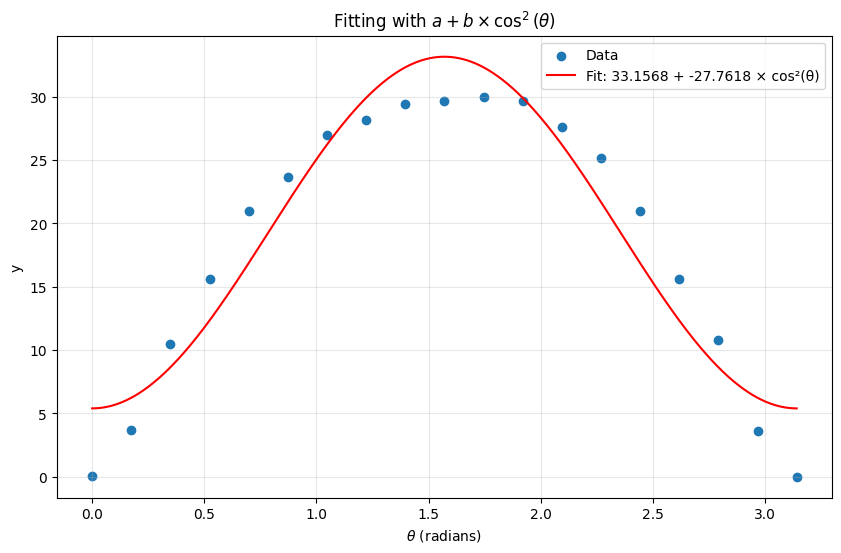

In [22]:
np.random.seed(42)
theta_true = np.linspace(0, np.pi, 19)
y_data  = [0.06,3.7,10.5,15.6,21,23.7,27,28.2,29.4,29.7,30,29.7,27.6,25.2,21,15.6,10.8,3.6,0]
print(theta_true)
# y_true = 0.3 + 0.7 * np.cos(theta_true)**2
# y_noise = 0.05 * np.random.randn(len(theta_true))
# y_data = y_true + y_noise
# y_err = 0.05 * np.ones_like(y_data)

# 방법 1: 기본 코사인 제곱 피팅
params, perr = fit_cos2(theta_true, y_data, y_err)
fig = plot_fit_result(theta_true, y_data,None, params)
fig.savefig('cos2_fit.png')